In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv(r"C:\Users\dawes\OneDrive\Desktop\Ecommerce-Return-Rate-Analysis\data\returns_sustainability_dataset.csv")

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nFirst 3 rows:")
df.head(3)

Shape: (5000, 23)

Columns:
 ['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Product_Category', 'Product_Price', 'Order_Quantity', 'Discount_Applied', 'Shipping_Method', 'Payment_Method', 'User_Age', 'User_Gender', 'User_Location', 'Return_Status', 'Return_Reason', 'Days_to_Return', 'Order_Value', 'Return_Cost', 'Profit_Loss', 'CO2_Emissions', 'Packaging_Waste', 'CO2_Saved', 'Waste_Avoided']

Null Values:
 Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
Discount_Applied    0
Shipping_Method     0
Payment_Method      0
User_Age            0
User_Gender         0
User_Location       0
Return_Status       0
Return_Reason       0
Days_to_Return      0
Order_Value         0
Return_Cost         0
Profit_Loss         0
CO2_Emissions       0
Packaging_Waste     0
CO2_Saved           0
Waste_Avoided       0
dtype: int64

Duplicate Rows: 0

First 3 rows:


,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
df['Order_Year']  = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Month_Name'] = df['Order_Date'].dt.strftime('%b')

In [ ]:
df['Return_Binary'] = (df['Return_Status'] == 'Returned').astype(int)

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("Cleaned shape:", df.shape)
print("\nNew columns added:", ['Order_Year', 'Order_Month', 'Order_Month_Name', 'Return_Binary'])
print("\nReturn_Binary distribution:\n", df['Return_Binary'].value_counts())
print(f"\nOverall Return Rate: {df['Return_Binary'].mean()*100:.1f}%")

Cleaned shape: (5000, 27)

New columns added: ['Order_Year', 'Order_Month', 'Order_Month_Name', 'Return_Binary']

Return_Binary distribution:
 Return_Binary
0    3550
1    1450
Name: count, dtype: int64

Overall Return Rate: 29.0%


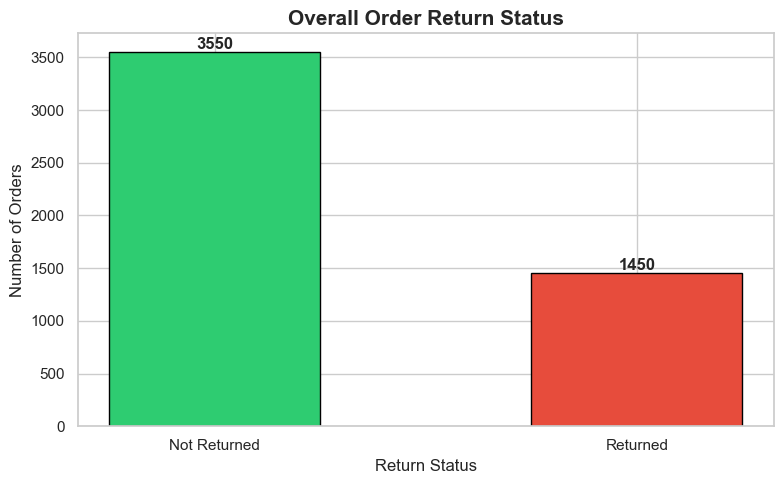

✅ Plot 1 saved → output/plot1_overall_return_count.png


In [13]:
counts = df['Return_Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=colors,
              edgecolor='black', width=0.5)
ax.set_title('Overall Order Return Status', fontsize=15, fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.set_xlabel('Return Status')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 30, str(val), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../output/plot1_overall_return_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved → output/plot1_overall_return_count.png")

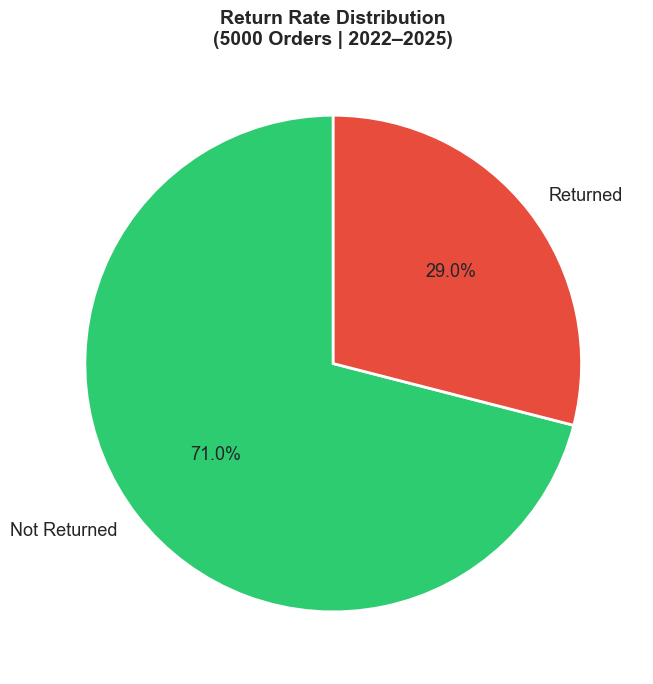

✅ Plot 2 saved → output/plot2_return_rate_pie.png


In [14]:
counts = df['Return_Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 13})
ax.set_title('Return Rate Distribution\n(5000 Orders | 2022–2025)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot2_return_rate_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved → output/plot2_return_rate_pie.png")

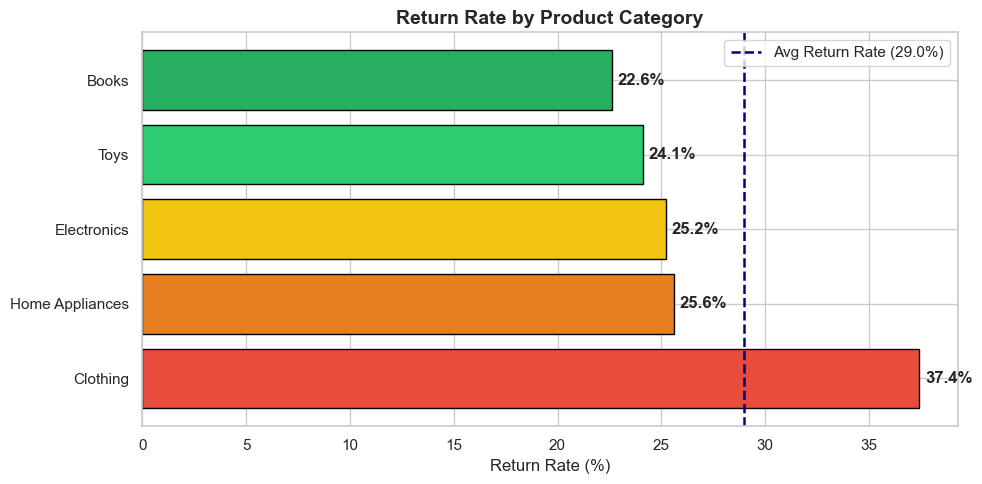

✅ Plot 3 saved → output/plot3_return_by_category.png


In [15]:
cat_stats = df.groupby('Product_Category').agg(
    Total_Orders   = ('Return_Binary', 'count'),
    Total_Returned = ('Return_Binary', 'sum')
).reset_index()
cat_stats['Return_Rate_%'] = (cat_stats['Total_Returned'] /
                               cat_stats['Total_Orders'] * 100).round(1)
cat_stats = cat_stats.sort_values('Return_Rate_%', ascending=False)

avg_rate = df['Return_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors_cat = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = ax.barh(cat_stats['Product_Category'], cat_stats['Return_Rate_%'],
               color=colors_cat, edgecolor='black')
ax.axvline(x=avg_rate, color='navy', linestyle='--',
           linewidth=1.8, label=f'Avg Return Rate ({avg_rate:.1f}%)')
ax.set_xlabel('Return Rate (%)')
ax.set_title('Return Rate by Product Category', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
for bar, val in zip(bars, cat_stats['Return_Rate_%']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot3_return_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved → output/plot3_return_by_category.png")

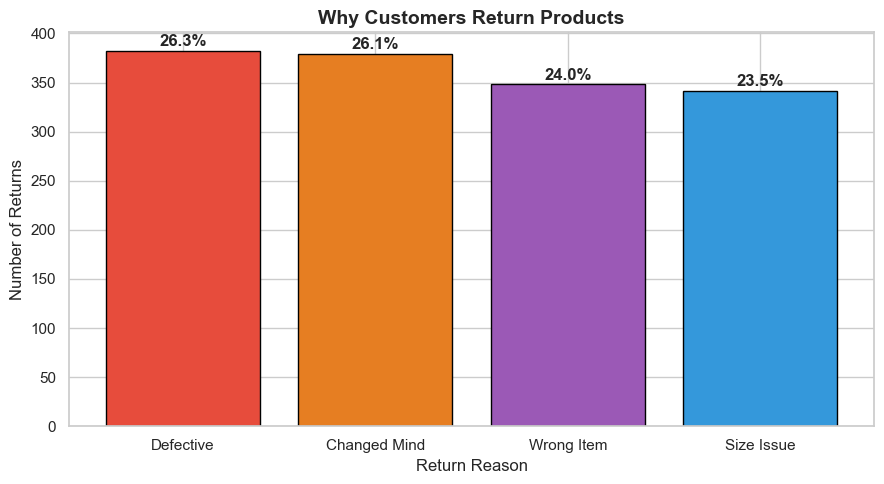

✅ Plot 4 saved → output/plot4_return_reasons.png


In [16]:
reasons = (df[df['Return_Reason'] != 'No Return']['Return_Reason']
           .value_counts().reset_index())
reasons.columns = ['Return_Reason', 'Count']
reasons['Percentage'] = (reasons['Count'] / reasons['Count'].sum() * 100).round(1)

colors_r = ['#e74c3c','#e67e22','#9b59b6','#3498db']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(reasons['Return_Reason'], reasons['Count'],
              color=colors_r, edgecolor='black')
ax.set_title('Why Customers Return Products', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Returns')
ax.set_xlabel('Return Reason')
for bar, pct in zip(bars, reasons['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{pct}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot4_return_reasons.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved → output/plot4_return_reasons.png")

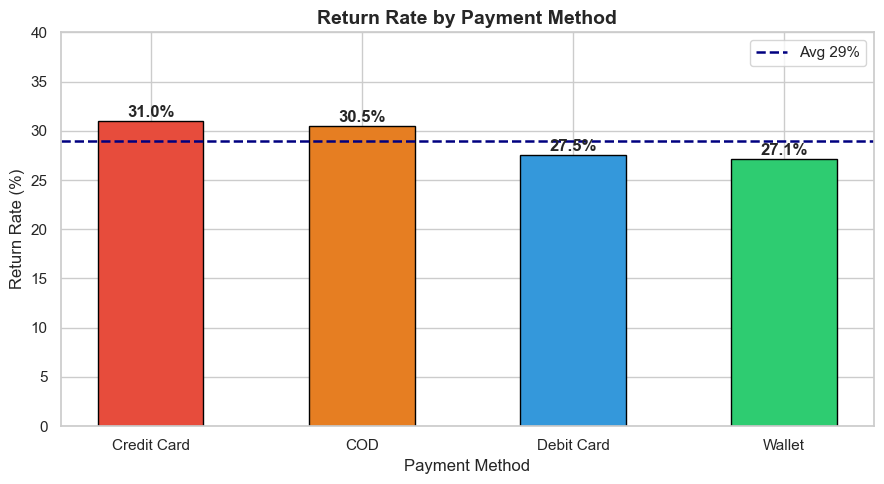

✅ Plot 5 saved → output/plot5_return_by_payment.png


In [17]:
pay = (df.groupby('Payment_Method')['Return_Binary']
       .mean().mul(100).round(1)
       .sort_values(ascending=False).reset_index())
pay.columns = ['Payment_Method', 'Return_Rate_%']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(pay['Payment_Method'], pay['Return_Rate_%'],
              color=['#e74c3c','#e67e22','#3498db','#2ecc71'],
              edgecolor='black', width=0.5)
ax.axhline(y=29, color='navy', linestyle='--',
           linewidth=1.8, label='Avg 29%')
ax.set_title('Return Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.set_xlabel('Payment Method')
ax.set_ylim(0, 40)
ax.legend(fontsize=11)
for bar, val in zip(bars, pay['Return_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.4, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot5_return_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 5 saved → output/plot5_return_by_payment.png")

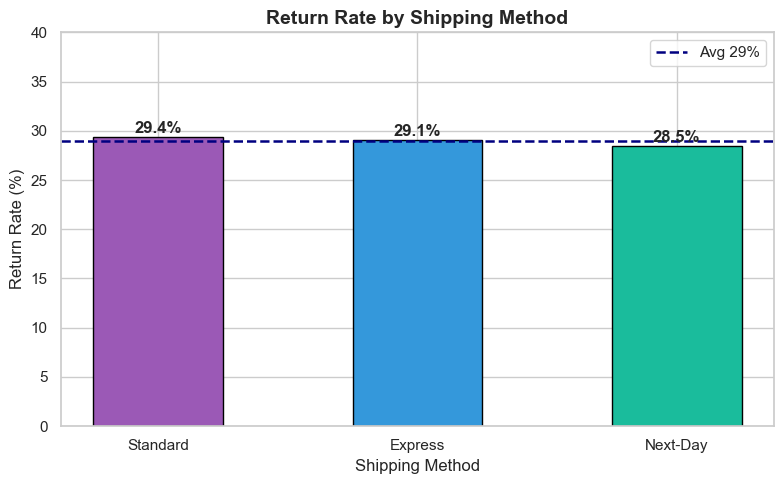

✅ Plot 6 saved → output/plot6_return_by_shipping.png


In [18]:
ship = (df.groupby('Shipping_Method')['Return_Binary']
        .mean().mul(100).round(1)
        .sort_values(ascending=False).reset_index())
ship.columns = ['Shipping_Method', 'Return_Rate_%']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ship['Shipping_Method'], ship['Return_Rate_%'],
              color=['#9b59b6','#3498db','#1abc9c'],
              edgecolor='black', width=0.5)
ax.axhline(y=29, color='navy', linestyle='--',
           linewidth=1.8, label='Avg 29%')
ax.set_title('Return Rate by Shipping Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.set_xlabel('Shipping Method')
ax.set_ylim(0, 40)
ax.legend(fontsize=11)
for bar, val in zip(bars, ship['Return_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.4, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot6_return_by_shipping.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6 saved → output/plot6_return_by_shipping.png")

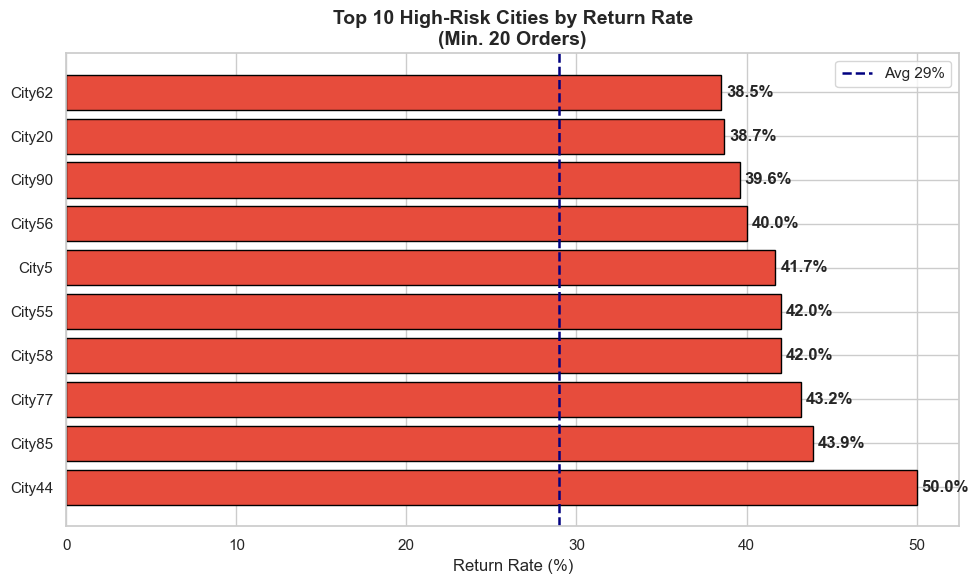

✅ Plot 7 saved → output/plot7_high_risk_cities.png


In [19]:
city_stats = df.groupby('User_Location').agg(
    Total    = ('Return_Binary', 'count'),
    Returned = ('Return_Binary', 'sum')
).reset_index()
city_stats['Return_Rate_%'] = (city_stats['Returned'] /
                                city_stats['Total'] * 100).round(1)
top_cities = (city_stats[city_stats['Total'] >= 20]
              .sort_values('Return_Rate_%', ascending=False)
              .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cities['User_Location'], top_cities['Return_Rate_%'],
               color='#e74c3c', edgecolor='black')
ax.axvline(x=29, color='navy', linestyle='--',
           linewidth=1.8, label='Avg 29%')
ax.set_xlabel('Return Rate (%)')
ax.set_title('Top 10 High-Risk Cities by Return Rate\n(Min. 20 Orders)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
for bar, val in zip(bars, top_cities['Return_Rate_%']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot7_high_risk_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 7 saved → output/plot7_high_risk_cities.png")

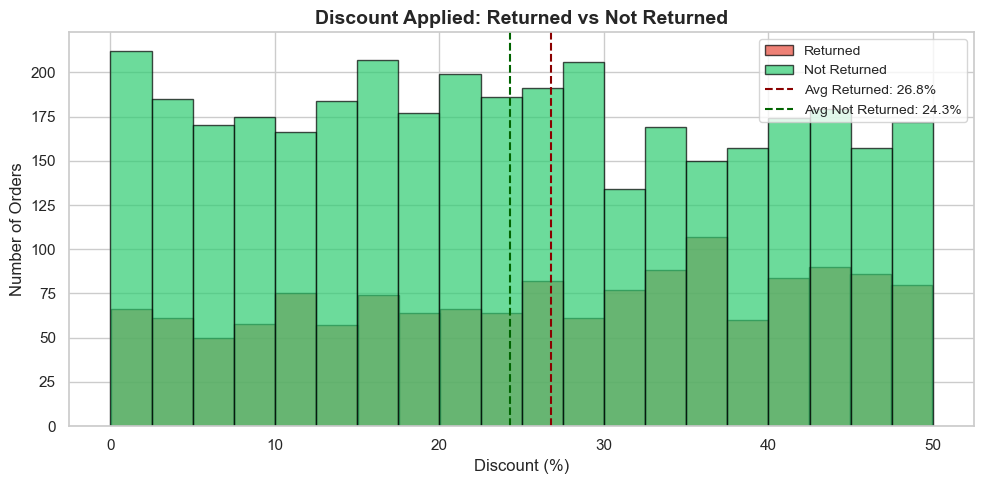

✅ Plot 8 saved → output/plot8_discount_vs_return.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Return_Status'] == 'Returned']['Discount_Applied'],
        bins=20, alpha=0.7, color='#e74c3c',
        label='Returned', edgecolor='black')
ax.hist(df[df['Return_Status'] == 'Not Returned']['Discount_Applied'],
        bins=20, alpha=0.7, color='#2ecc71',
        label='Not Returned', edgecolor='black')
ax.set_title('Discount Applied: Returned vs Not Returned',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Number of Orders')
ax.legend(fontsize=11)

# Avg lines
avg_ret     = df[df['Return_Status'] == 'Returned']['Discount_Applied'].mean()
avg_not_ret = df[df['Return_Status'] == 'Not Returned']['Discount_Applied'].mean()
ax.axvline(avg_ret, color='darkred', linestyle='--',
           linewidth=1.5, label=f'Avg Returned: {avg_ret:.1f}%')
ax.axvline(avg_not_ret, color='darkgreen', linestyle='--',
           linewidth=1.5, label=f'Avg Not Returned: {avg_not_ret:.1f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../output/plot8_discount_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 8 saved → output/plot8_discount_vs_return.png")

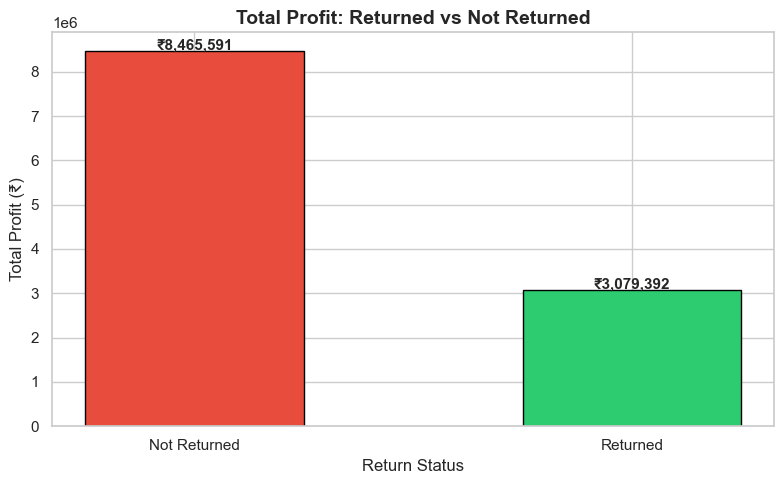

✅ Plot 9 saved → output/plot9_profit_impact.png


In [21]:
profit = df.groupby('Return_Status')['Profit_Loss'].sum().reset_index()
profit.columns = ['Return_Status', 'Total_Profit']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(profit['Return_Status'], profit['Total_Profit'],
              color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax.set_title('Total Profit: Returned vs Not Returned',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Total Profit (₹)')
ax.set_xlabel('Return Status')
for bar, val in zip(bars, profit['Total_Profit']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 30000,
            f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../output/plot9_profit_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 9 saved → output/plot9_profit_impact.png")

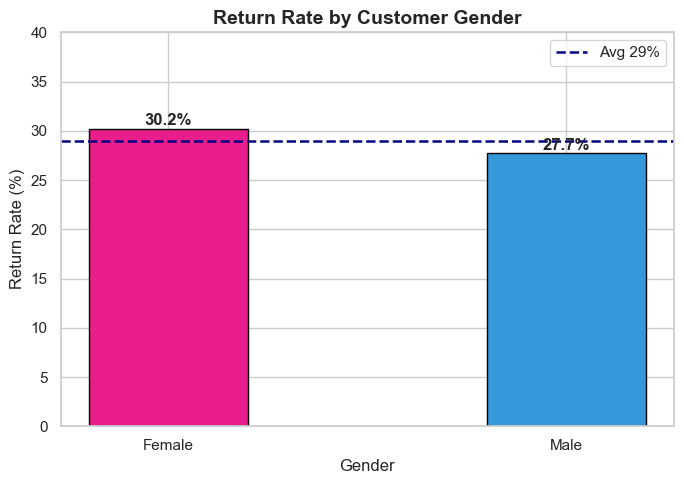

✅ Plot 10 saved → output/plot10_return_by_gender.png


In [22]:
gender = (df.groupby('User_Gender')['Return_Binary']
          .mean().mul(100).round(1).reset_index())
gender.columns = ['Gender', 'Return_Rate_%']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gender['Gender'], gender['Return_Rate_%'],
              color=['#e91e8c', '#3498db'],
              edgecolor='black', width=0.4)
ax.axhline(y=29, color='navy', linestyle='--',
           linewidth=1.8, label='Avg 29%')
ax.set_title('Return Rate by Customer Gender',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.set_xlabel('Gender')
ax.set_ylim(0, 40)
ax.legend(fontsize=11)
for bar, val in zip(bars, gender['Return_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.4, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot10_return_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 10 saved → output/plot10_return_by_gender.png")


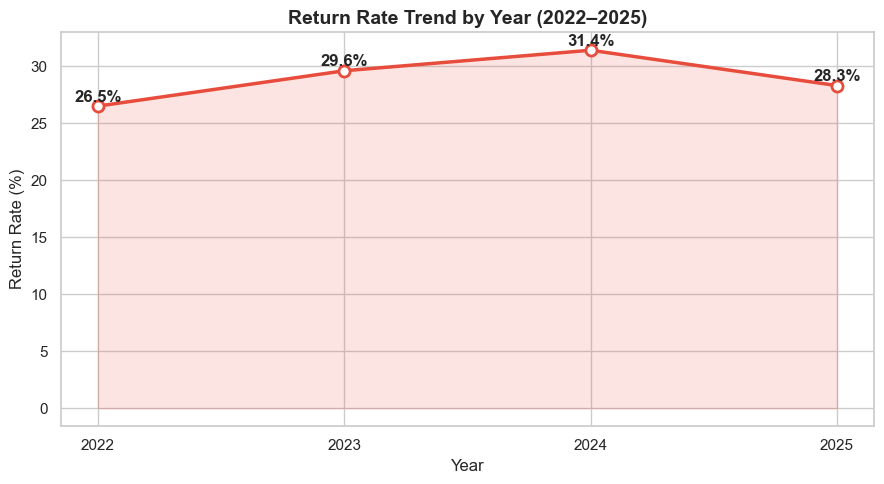

✅ Plot 11 saved → output/plot11_yearly_trend.png


In [23]:
yearly = df.groupby('Order_Year').agg(
    Total    = ('Return_Binary', 'count'),
    Returned = ('Return_Binary', 'sum')
).reset_index()
yearly['Return_Rate_%'] = (yearly['Returned'] /
                            yearly['Total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly['Order_Year'], yearly['Return_Rate_%'],
        marker='o', color='#e74c3c', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(yearly['Order_Year'], yearly['Return_Rate_%'],
                alpha=0.15, color='#e74c3c')
ax.set_title('Return Rate Trend by Year (2022–2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.set_xlabel('Year')
ax.set_xticks(yearly['Order_Year'])
for _, row in yearly.iterrows():
    ax.text(row['Order_Year'], row['Return_Rate_%'] + 0.4,
            f"{row['Return_Rate_%']}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/plot11_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 11 saved → output/plot11_yearly_trend.png")

In [24]:
product_stats = df.groupby(['Product_ID', 'Product_Category']).agg(
    Total_Orders      = ('Return_Binary', 'count'),
    Total_Returned    = ('Return_Binary', 'sum'),
    Avg_Price         = ('Product_Price', 'mean'),
    Avg_Discount      = ('Discount_Applied', 'mean'),
    Total_Return_Cost = ('Return_Cost', 'sum')
).reset_index()

product_stats['Return_Rate_%'] = (product_stats['Total_Returned'] /
                                   product_stats['Total_Orders'] * 100).round(1)
product_stats['Avg_Price']    = product_stats['Avg_Price'].round(2)
product_stats['Avg_Discount'] = product_stats['Avg_Discount'].round(2)

# High risk = return rate >= 40%
high_risk = (product_stats[product_stats['Return_Rate_%'] >= 40]
             .sort_values('Return_Rate_%', ascending=False)
             .reset_index(drop=True))

print(f"✅ Total High-Risk Products (≥40% return rate): {len(high_risk)}")
print(high_risk.head(10))

high_risk.to_csv('../output/high_risk_products.csv', index=False)
print("\n✅ Saved → output/high_risk_products.csv")

✅ Total High-Risk Products (≥40% return rate): 679
  Product_ID Product_Category  Total_Orders  Total_Returned  Avg_Price  \
0   PROD0001         Clothing             1               1    1064.57   
1   PROD0122            Books             2               2     863.00   
2   PROD0347         Clothing             2               2     834.01   
3   PROD0346            Books             1               1     761.00   
4   PROD0125            Books             1               1     124.40   
5   PROD0125  Home Appliances             1               1     286.64   
6   PROD0343         Clothing             4               4     995.38   
7   PROD0341            Books             1               1    1301.74   
8   PROD0128            Books             1               1    1745.63   
9   PROD0128         Clothing             3               3    1555.58   

   Avg_Discount  Total_Return_Cost  Return_Rate_%  
0          9.18                200          100.0  
1         18.31               

In [25]:
print("=" * 55)
print("   EDA COMPLETE — SUMMARY OF KEY FINDINGS")
print("=" * 55)
print(f"  Total Orders Analysed  : 5,000")
print(f"  Overall Return Rate    : 29.0%")
print(f"  Highest Risk Category  : Clothing (37.4%)")
print(f"  Lowest Risk Category   : Books (22.6%)")
print(f"  Top Return Reason      : Defective (26.3%)")
print(f"  Highest Risk City      : City44 (50.0%)")
print(f"  Riskiest Payment Method: Credit Card (31.0%)")
print(f"  Total Return Cost      : ₹2,90,000")
print(f"  High Risk Products     : {len(high_risk)}")
print("=" * 55)
print("\n✅ All 11 plots saved in output/")
print("✅ high_risk_products.csv saved in output/")
print("\n🚀 Ready for Day 2 — Machine Learning!")

   EDA COMPLETE — SUMMARY OF KEY FINDINGS
  Total Orders Analysed  : 5,000
  Overall Return Rate    : 29.0%
  Highest Risk Category  : Clothing (37.4%)
  Lowest Risk Category   : Books (22.6%)
  Top Return Reason      : Defective (26.3%)
  Highest Risk City      : City44 (50.0%)
  Riskiest Payment Method: Credit Card (31.0%)
  Total Return Cost      : ₹2,90,000
  High Risk Products     : 679

✅ All 11 plots saved in output/
✅ high_risk_products.csv saved in output/

🚀 Ready for Day 2 — Machine Learning!
